# Examen Python

## Programación y matemáticas para la ciencia de datos.
## Edilberto Antonio Gómez García

In [1]:
from dotenv import load_dotenv
from pathlib import Path
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Problema 1

In [8]:
path = kagglehub.dataset_download("sudalairajkumar/novel-corona-virus-2019-dataset")
covid = pd.read_csv(f"{path}/covid_19_data.csv")
# se muestran las primeras filas
covid.head()

Using Colab cache for faster access to the 'novel-corona-virus-2019-dataset' dataset.


,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,1,01/22/2020,Anhui,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
1,2,01/22/2020,Beijing,Mainland China,1/22/2020 17:00,14.0,0.0,0.0
2,3,01/22/2020,Chongqing,Mainland China,1/22/2020 17:00,6.0,0.0,0.0
3,4,01/22/2020,Fujian,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
4,5,01/22/2020,Gansu,Mainland China,1/22/2020 17:00,0.0,0.0,0.0


### Actividad 1

In [9]:
# se muestra el número de filas y columnas
filas, columnas = covid.shape
print(f'El número de filas es {filas} y el número de columnas es {columnas}')

El número de filas es 306429 y el número de columnas es 8


In [16]:
# se muestra el nombre de las columnas
variables = list(covid.columns)
print(f'Las variables de la tabla son {variables}')

Las variables de la tabla son ['SNo', 'ObservationDate', 'Province/State', 'Country/Region', 'Last Update', 'Confirmed', 'Deaths', 'Recovered']


In [19]:
# se muestra el tipo de las variables
print(f'el tipo de datos de las columnas son\n{covid.dtypes}')

el tipo de datos de las columnas son
SNo                  int64
ObservationDate     object
Province/State      object
Country/Region      object
Last Update         object
Confirmed          float64
Deaths             float64
Recovered          float64
dtype: object


### Actividad 2

In [32]:
covid_mexico = covid[covid['Country/Region'] == 'Mexico'].copy()
covid_mexico.head()

,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered,Total
83,84,2020-01-23,NaN,Mexico,1/23/20 17:00,0.0,0.0,0.0,1097.0
2753,2754,2020-02-28,NaN,Mexico,2020-02-28T15:03:26,1.0,0.0,0.0,84125.0
2842,2843,2020-02-29,NaN,Mexico,2020-02-29T21:13:17,4.0,0.0,0.0,86012.0
2965,2966,2020-03-01,NaN,Mexico,2020-03-01T23:33:03,5.0,0.0,0.0,88368.0
3097,3098,2020-03-02,NaN,Mexico,2020-03-01T23:33:03,5.0,0.0,0.0,90311.0


La columna correspondiente a la fecha se llama `ObservationDate`

La columna correspondiente a la casos confirmados se llama `Confirmed`

La columna correspondiente a los recuperados se llama `Recovered`

La columna correspondiente a los fallecidos se llama `Deaths`

### Actividad 3

Text(0, 0.5, 'Casos confirmados')

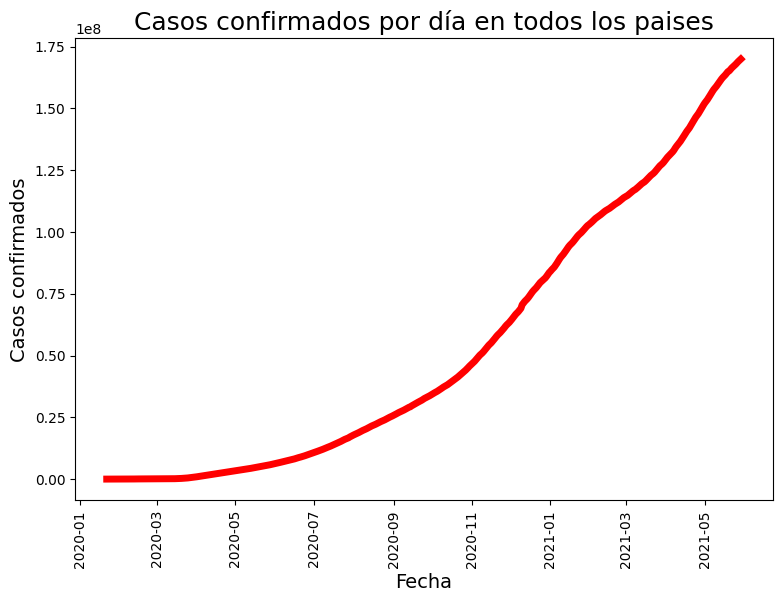

In [37]:
covid['ObservationDate'] = pd.to_datetime(covid['ObservationDate'], errors='coerce')
covid_diarios = covid.groupby('ObservationDate')['Confirmed'].sum().reset_index()
fig = plt.figure(figsize=(9, 6))
plt.plot(covid_diarios['ObservationDate'], covid_diarios['Confirmed'], color='red', lw = 5)
plt.xticks(rotation=90)
plt.title('Casos confirmados por día en todos los paises', fontsize = 18)
plt.xlabel('Fecha', fontsize = 14)
plt.ylabel('Casos confirmados', fontsize = 14)

### Actividad 4

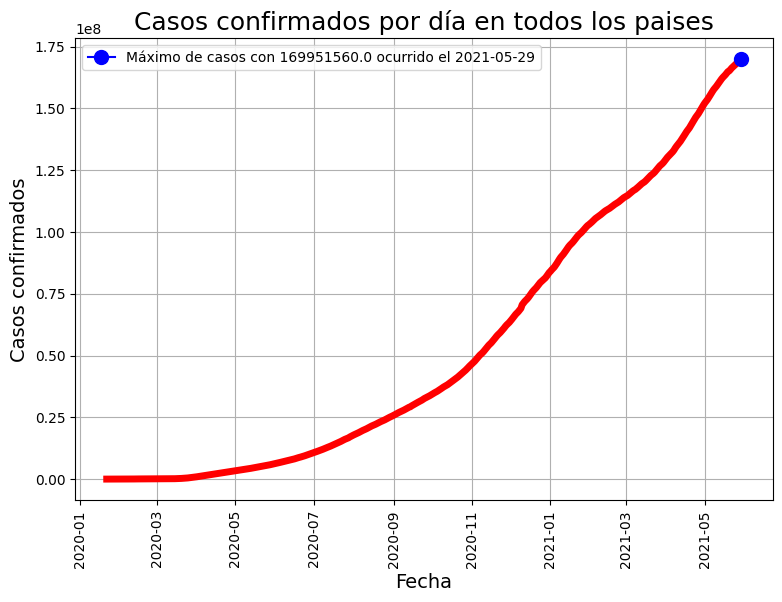

In [48]:
maximo = np.max(covid_diarios['Confirmed'])
fecha_maximo = covid_diarios.loc[covid_diarios['Confirmed'] == maximo]['ObservationDate']
fig = plt.figure(figsize=(9, 6))
plt.plot(covid_diarios['ObservationDate'], covid_diarios['Confirmed'], color='red', lw = 5)
plt.plot(fecha_maximo, maximo, color='blue', marker='o', markersize='10', label=f'Máximo de casos con {maximo} ocurrido el {fecha_maximo.iloc[0].strftime('%Y-%m-%d')}')
plt.xticks(rotation=90)
plt.title('Casos confirmados por día en todos los paises', fontsize = 18)
plt.xlabel('Fecha', fontsize = 14)
plt.ylabel('Casos confirmados', fontsize = 14)
plt.grid()
plt.legend()

In [49]:
covid.value_counts('Country/Region')

,count
Country/Region,
Russia,30251
US,26740
Japan,18059
Mainland China,15758
India,13182
...,...
Azerbaijan,1
"('St. Martin',)",1
North Ireland,1


### Actividad 5

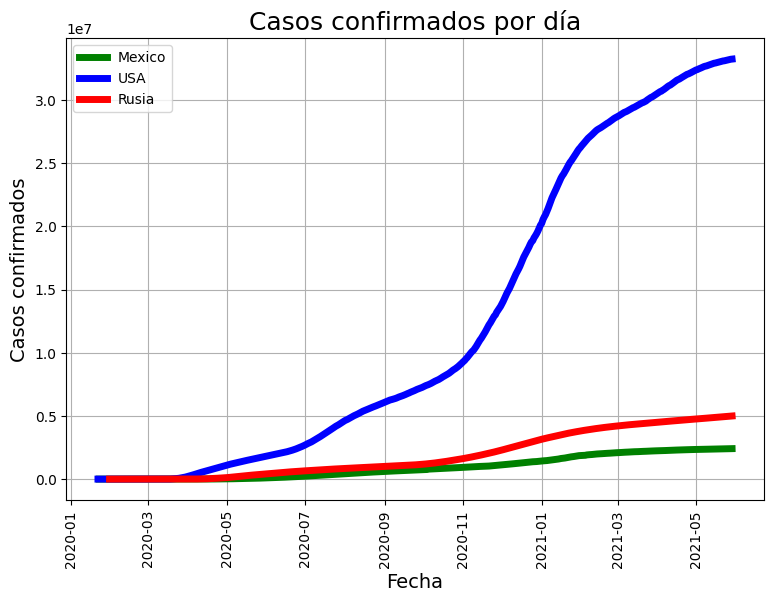

In [51]:
covid_mexico['ObservationDate'] = pd.to_datetime(covid['ObservationDate'], errors='coerce')
covid_mexico_diarios = covid_mexico.groupby('ObservationDate')['Confirmed'].sum().reset_index()

covid_usa = covid[covid['Country/Region'] == 'US'].copy()
covid_usa['ObservationDate'] = pd.to_datetime(covid_usa['ObservationDate'], errors='coerce')
covid_usa_diarios = covid_usa.groupby('ObservationDate')['Confirmed'].sum().reset_index()

covid_rusia = covid[covid['Country/Region'] == 'Russia'].copy()
covid_rusia['ObservationDate'] = pd.to_datetime(covid_rusia['ObservationDate'], errors='coerce')
covid_rusia_diarios = covid_rusia.groupby('ObservationDate')['Confirmed'].sum().reset_index()

fig = plt.figure(figsize=(9, 6))
plt.plot(covid_mexico_diarios['ObservationDate'], covid_mexico_diarios['Confirmed'], color='green', lw = 5, label='Mexico')
plt.plot(covid_usa_diarios['ObservationDate'], covid_usa_diarios['Confirmed'], color='blue', lw = 5, label='USA')
plt.plot(covid_rusia_diarios['ObservationDate'], covid_rusia_diarios['Confirmed'], color='red', lw = 5, label='Rusia')
plt.xticks(rotation=90)
plt.title('Casos confirmados por día', fontsize = 18)
plt.xlabel('Fecha', fontsize = 14)
plt.ylabel('Casos confirmados', fontsize = 14)
plt.legend()
plt.grid()

### Actividad 6

Las gráficas nos permiten distinguir el aumento/disminución de los casos diarios que van teniendo los paises, para entender el comportamiento y evolución del virus

## Problema 2

In [52]:
path = kagglehub.dataset_download("camnugent/sandp500")
bolsa = pd.read_csv(f"{path}/all_stocks_5yr.csv")
# se muestran las primeras filas
bolsa.head()

100%|██████████| 19.3M/19.3M [00:00<00:00, 215MB/s]

Extracting files...


,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


### Actividad 1

In [54]:
bolsa.dtypes

,0
date,object
open,float64
high,float64
low,float64
close,float64
volume,int64
Name,object


In [55]:
bolsa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619040 non-null  object 
 1   open    619029 non-null  float64
 2   high    619032 non-null  float64
 3   low     619032 non-null  float64
 4   close   619040 non-null  float64
 5   volume  619040 non-null  int64  
 6   Name    619040 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 33.1+ MB


In [56]:
bolsa.describe()

,open,high,low,close,volume
count,619029.000000,619032.000000,619032.000000,619040.000000,6.190400e+05
mean,83.023334,83.778311,82.256096,83.043763,4.321823e+06
std,97.378769,98.207519,96.507421,97.389748,8.693610e+06
min,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,40.220000,40.620000,39.830000,40.245000,1.070320e+06
50%,62.590000,63.150000,62.020000,62.620000,2.082094e+06
75%,94.370000,95.180000,93.540000,94.410000,4.284509e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


### Actividad 2

In [61]:
bolsa_3 = bolsa[bolsa['Name'].isin(['NVDA', 'MSFT', 'AMZN'])].copy()
bolsa_3

,date,open,high,low,close,volume,Name
46387,2013-02-08,261.40,265.25,260.555,261.95,3879078,AMZN
46388,2013-02-11,263.20,263.25,256.600,257.21,3403403,AMZN
46389,2013-02-12,259.19,260.16,257.000,258.70,2938660,AMZN
46390,2013-02-13,261.53,269.96,260.300,269.47,5292996,AMZN
46391,2013-02-14,267.37,270.65,265.400,269.24,3462780,AMZN
...,...,...,...,...,...,...,...
423887,2018-02-01,238.52,246.90,238.060,240.50,12980572,NVDA
423888,2018-02-02,237.00,237.97,231.170,233.52,17961555,NVDA
423889,2018-02-05,227.00,233.23,205.000,213.70,29130140,NVDA
423890,2018-02-06,204.40,225.70,204.000,225.58,27870031,NVDA


se seleccionaron las empresas de Nvidia, Microsoft y de Amazon

### Actividad 3

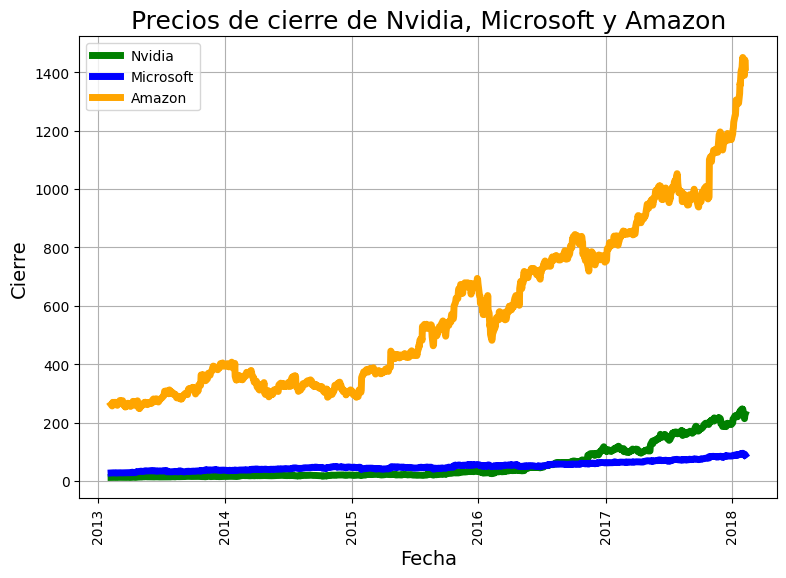

In [64]:
bolsa_nvidia = bolsa_3[bolsa_3['Name'] == 'NVDA'].copy()
bolsa_nvidia['date'] = pd.to_datetime(bolsa_nvidia['date'], errors='coerce')
bolsa_microsoft = bolsa_3[bolsa_3['Name'] == 'MSFT'].copy()
bolsa_microsoft['date'] = pd.to_datetime(bolsa_microsoft['date'], errors='coerce')
bolsa_amazon = bolsa_3[bolsa_3['Name'] == 'AMZN'].copy()
bolsa_amazon['date'] = pd.to_datetime(bolsa_amazon['date'], errors='coerce')
fig = plt.figure(figsize=(9, 6))
plt.plot(bolsa_nvidia['date'], bolsa_nvidia['close'], color='green', lw = 5, label='Nvidia')
plt.plot(bolsa_microsoft['date'], bolsa_microsoft['close'], color='blue', lw = 5, label='Microsoft')
plt.plot(bolsa_amazon['date'], bolsa_amazon['close'], color='orange', lw = 5, label='Amazon')
plt.xticks(rotation=90)
plt.title('Precios de cierre de Nvidia, Microsoft y Amazon', fontsize = 18)
plt.xlabel('Fecha', fontsize = 14)
plt.ylabel('Cierre', fontsize = 14)
plt.legend()
plt.grid()

### Actividad 4

In [65]:
media_nvidia = np.mean(bolsa_nvidia['close'])
media_microsoft = np.mean(bolsa_microsoft['close'])
media_amazon = np.mean(bolsa_amazon['close'])

varianza_nvidia = np.var(bolsa_nvidia['close'])
varianza_microsoft = np.var(bolsa_microsoft['close'])
varianza_amazon = np.var(bolsa_amazon['close'])

desviacion_estandar_nvidia = np.std(bolsa_nvidia['close'])
desviacion_estandar_microsoft = np.std(bolsa_microsoft['close'])
desviacion_estandar_amazon = np.std(bolsa_amazon['close'])

resultado = {'Nvidia':[media_nvidia, varianza_nvidia, desviacion_estandar_nvidia],
             'Microsoft':[media_microsoft, varianza_microsoft, desviacion_estandar_microsoft],
             'Amazon':[media_amazon, varianza_amazon, desviacion_estandar_amazon]}
resultado = pd.DataFrame(resultado, index=['Media', 'Varianza', 'Desviación estándar'])
resultado

,Nvidia,Microsoft,Amazon
Media,56.369368,51.063081,576.880041
Varianza,3552.274168,220.410166,79743.084415
Desviación estándar,59.600958,14.846217,282.388180


### Actividad 5

In [78]:
bolsa_nvidia = bolsa_nvidia.sort_values(by='date')
bolsa_nvidia['rendimiento'] = bolsa_nvidia['close'].pct_change()

bolsa_microsoft = bolsa_microsoft.sort_values(by='date')
bolsa_microsoft['rendimiento'] = bolsa_microsoft['close'].pct_change()

bolsa_amazon = bolsa_amazon.sort_values(by='date')
bolsa_amazon['rendimiento'] = bolsa_amazon['close'].pct_change()


### Actividad 6

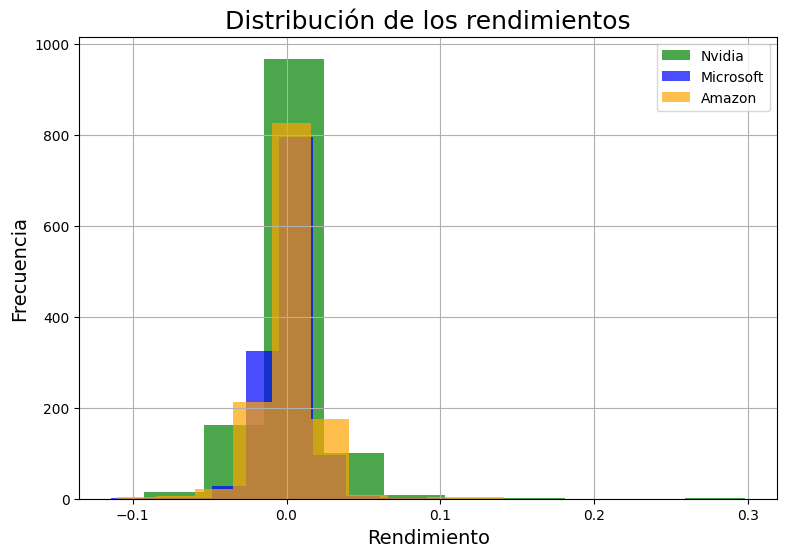

In [72]:
fig = plt.figure(figsize=(9, 6))
plt.hist(bolsa_nvidia['rendimiento'], color='green', alpha = 0.7, label='Nvidia')
plt.hist(bolsa_microsoft['rendimiento'], color='blue', alpha = 0.7, label='Microsoft')
plt.hist(bolsa_amazon['rendimiento'], color='orange', alpha = 0.7, label='Amazon')
plt.title('Distribución de los rendimientos', fontsize = 18)
plt.xlabel('Rendimiento', fontsize = 14)
plt.ylabel('Frecuencia', fontsize = 14)
plt.legend()
plt.grid()

### Actividad 7

/tmp/ipykernel_4143/1192384357.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


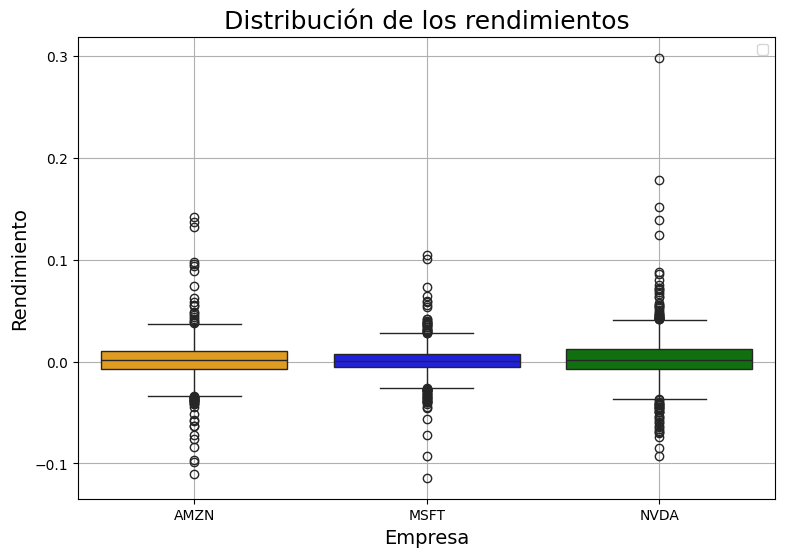

In [84]:
bolsa_3 = bolsa_3.sort_values(by=['Name', 'date'])
bolsa_3['rendimiento'] = bolsa_3.groupby('Name')['close'].pct_change()
colores = {
    'NVDA': 'green',
    'AMZN': 'orange',
    'MSFT': 'blue'
}
fig = plt.figure(figsize=(9, 6))
sns.boxplot(data=bolsa_3, x='Name', y='rendimiento', hue='Name', palette=colores, legend=False)
plt.title('Distribución de los rendimientos', fontsize = 18)
plt.ylabel('Rendimiento', fontsize = 14)
plt.xlabel('Empresa', fontsize = 14)
plt.legend()
plt.grid()

No hay una verdadera diferencia, ya que el 50% central de los datos se encuentran alrededor del 0, y los tres tienen varios valores atípicos

### Actividad 8

In [85]:
media_nvidia = np.mean(bolsa_nvidia['rendimiento'])
media_microsoft = np.mean(bolsa_microsoft['rendimiento'])
media_amazon = np.mean(bolsa_amazon['rendimiento'])

varianza_nvidia = np.var(bolsa_nvidia['rendimiento'])
varianza_microsoft = np.var(bolsa_microsoft['rendimiento'])
varianza_amazon = np.var(bolsa_amazon['rendimiento'])

desviacion_estandar_nvidia = np.std(bolsa_nvidia['rendimiento'])
desviacion_estandar_microsoft = np.std(bolsa_microsoft['rendimiento'])
desviacion_estandar_amazon = np.std(bolsa_amazon['rendimiento'])

resultado = {'Nvidia':[media_nvidia, varianza_nvidia, desviacion_estandar_nvidia],
             'Microsoft':[media_microsoft, varianza_microsoft, desviacion_estandar_microsoft],
             'Amazon':[media_amazon, varianza_amazon, desviacion_estandar_amazon]}
resultado = pd.DataFrame(resultado, index=['Media', 'Varianza', 'Desviación estándar'])
resultado

,Nvidia,Microsoft,Amazon
Media,0.002563,0.001039,0.001508
Varianza,0.000499,0.000202,0.000332
Desviación estándar,0.022342,0.014205,0.018228


Como se puede observar tanto en la gráfica de boxplot (debido a que hay un valor atípico bastante alto) como en el resultado de la varianza, la desviación estándar es más grande en Nvidia que en las otras 2, por lo que esa empresa tiene mayor variabilidad.

## Problema 3

In [87]:
super = pd.read_csv('supermarket_sheet.csv')
# se muestran las primeras filas
super.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


### Actividad 1

In [88]:
# se muestra el tamaño de la tabla
filas, columnas = super.shape
print(f'El número de observaciones es {filas} y el número de variables es {columnas}')

El número de observaciones es 1000 y el número de variables es 17


In [90]:
# se muestran los tipos de datos
print(f'El tipo de datos de las columnas son\n{super.dtypes}')

El tipo de datos de las columnas son
Invoice ID                  object
Branch                      object
City                        object
Customer type               object
Gender                      object
Product line                object
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Total                      float64
Date                        object
Time                        object
Payment                     object
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object


In [91]:
# se muestra si hay valores faltantes
super.isnull().sum()

,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Total,0


### Actividad 2

In [94]:
ventas = super.groupby('Product line')['Quantity'].sum().reset_index().sort_values(by='Quantity', ascending=False)
ventas

,Product line,Quantity
0,Electronic accessories,971
2,Food and beverages,952
5,Sports and travel,920
4,Home and lifestyle,911
1,Fashion accessories,902
3,Health and beauty,854


Text(0, 0.5, 'Ventas')

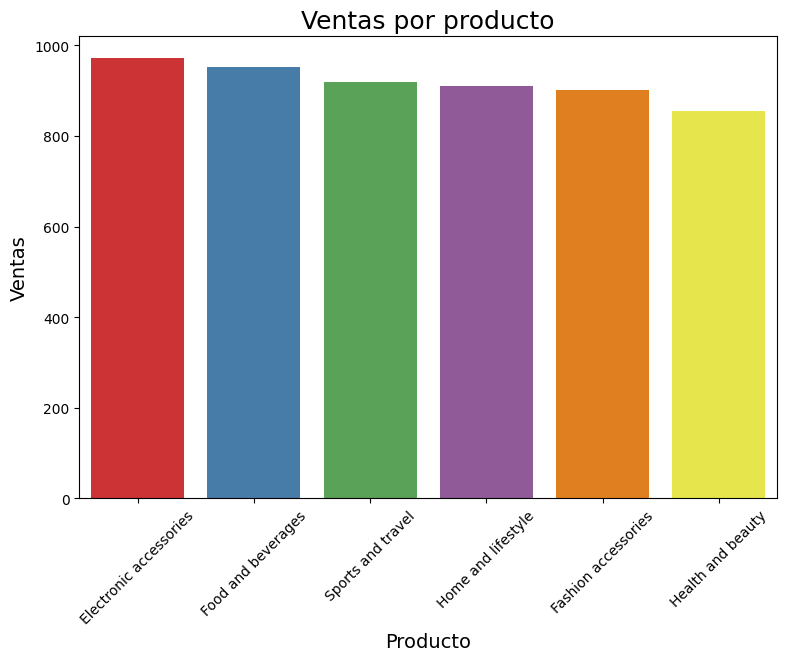

In [102]:
fig = fig = plt.figure(figsize=(9, 6))
sns.barplot(data=ventas, x='Product line', y='Quantity', hue='Product line', palette='Set1', legend=False)
plt.title('Ventas por producto', fontsize = 18)
plt.xlabel('Producto', fontsize = 14)
plt.xticks(rotation=45)
plt.ylabel('Ventas', fontsize = 14)

### Actividad 3

In [106]:
ingresos = super.groupby('Product line')['Total'].sum().reset_index().sort_values(by='Total', ascending=False)
ingresos

,Product line,Total
2,Food and beverages,56144.8440
5,Sports and travel,55122.8265
0,Electronic accessories,54337.5315
1,Fashion accessories,54305.8950
4,Home and lifestyle,53861.9130
3,Health and beauty,49193.7390


Text(0, 0.5, 'Ingresos')

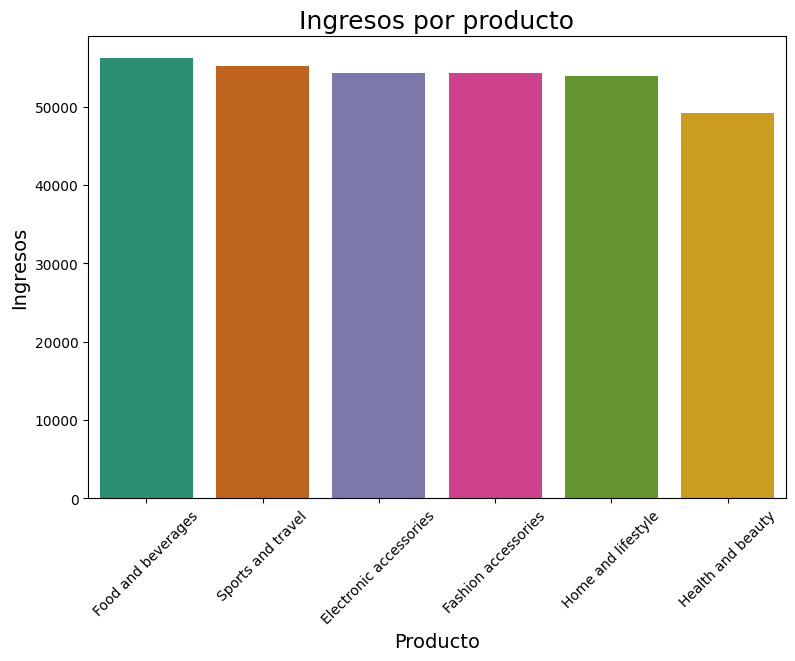

In [108]:
fig = fig = plt.figure(figsize=(9, 6))
sns.barplot(data=ingresos, x='Product line', y='Total', hue='Product line', palette='Dark2', legend=False)
plt.title('Ingresos por producto', fontsize = 18)
plt.xlabel('Producto', fontsize = 14)
plt.xticks(rotation=45)
plt.ylabel('Ingresos', fontsize = 14)

### Actividad 4

In [116]:
sucursal = super.groupby('Branch')['Invoice ID'].nunique().reset_index().sort_values(by='Invoice ID', ascending=False)

sucursal.rename(columns={'Invoice ID': 'Total ventas'}, inplace=True)
sucursal

,Branch,Total ventas
0,A,340
1,B,332
2,C,328


Text(0, 0.5, 'Ingresos')

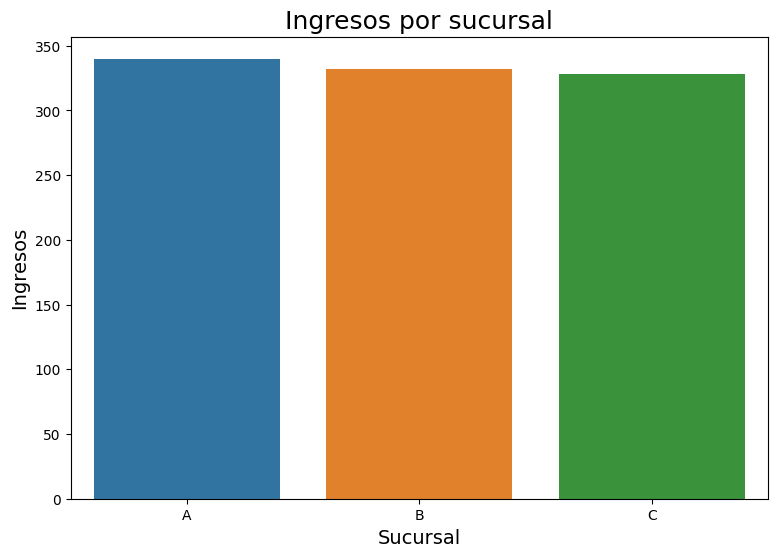

In [118]:
fig = fig = plt.figure(figsize=(9, 6))
sns.barplot(data=sucursal, x='Branch', y='Total ventas', hue='Branch', palette='tab10', legend=False)
plt.title('Ingresos por sucursal', fontsize = 18)
plt.xlabel('Sucursal', fontsize = 14)
plt.ylabel('Ingresos', fontsize = 14)

Considero que este tipo de gráfica puede mostrar más claramente las diferencias, incluso no son muy notorias, como en este caso, al contrario si fuera una gráfica de pastel, no se notaría demasiado.

### Actividad 5

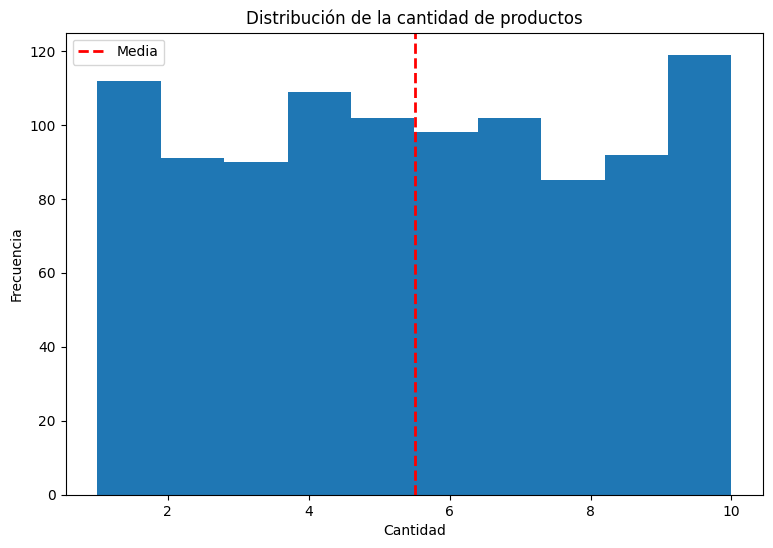

In [125]:
media_cantidad = np.mean(super['Quantity'])
varianza_cantidad = np.var(super['Quantity'])
desviacion_estandar_cantidad = np.std(super['Quantity'])

fig = plt.figure(figsize=(9, 6))
plt.hist(super['Quantity'])
plt.axvline(x=media_cantidad, color='red', linestyle='dashed', linewidth=2, label='Media')
plt.xlabel('Cantidad')
plt.ylabel('Frecuencia')
plt.title('Distribución de la cantidad de productos')
plt.legend()

### Actividad 6

Parece que los productos más demandados son los electrónicos, ya que son los más comprados.